In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv


# AICE Associate 실전 모의고사 5회
- 데이터셋 : Loan Approval Prediction Dataset
- 예측 대상 : loan_status (0: 거절, 1: 승인)

## 문제 1.데이터를 불러와 `상위 5개 행`, `데이터 크기`, `컬럼명`을 확인하시오.

In [31]:
import pandas as pd 
df = pd.read_csv('/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv')

In [32]:
df.head() # 상위 5개 행

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [33]:
df.shape # 데이터 크기

(45000, 14)

In [34]:
df.columns # 컬럼명

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

## 문제 2.각 컬럼의 `데이터 타입`, `Non-null 개수`를 확인하시오.

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## 문제 3.결측치 개수를 출력하시오.

In [36]:
df.isnull().sum().sum()

np.int64(0)

## 문제 4.loan_int_rate의 결측치를 평균값으로 대체하시오.

In [37]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())

## 문제 5.person_home_ownership의 고유값을 확인하시오.

In [38]:
df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

## 문제 6.loan_status별 데이터 개수를 출력하시오.

In [68]:
df.groupby('loan_status').size()

loan_status
0    35000
1    10000
dtype: int64

In [66]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

## 문제 7.loan_status 분포를 CountPlot으로 시각화하시오.

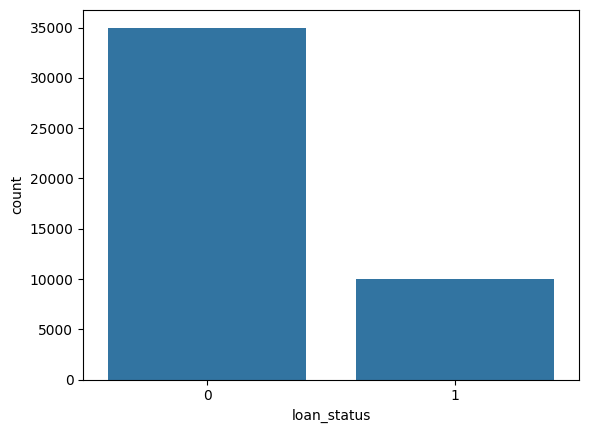

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(df, x='loan_status')
plt.show()

## 문제 8.person_income 분포를 Histogram으로 출력하시오.

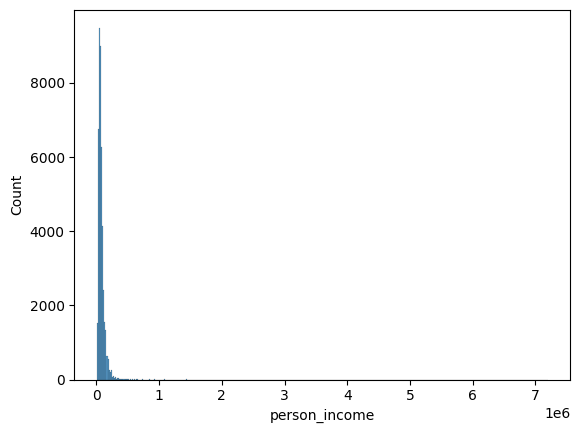

In [67]:
sns.histplot(df, x='person_income')
plt.show()

## 문제 9.loan_amnt와 person_income 관계를 ScatterPlot으로 시각화하시오.

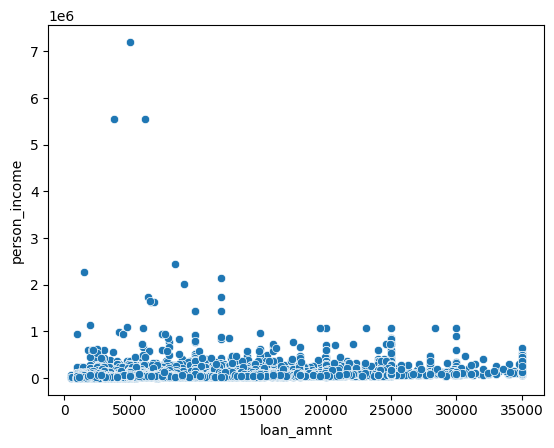

In [42]:
sns.scatterplot(df, x='loan_amnt', y='person_income')
plt.show()

## 문제 10.person_home_ownership별 평균 loan_amnt를 구하시오.

In [43]:
df.groupby('person_home_ownership')['loan_amnt'].mean()

person_home_ownership
MORTGAGE    10716.832225
OTHER       11282.324786
OWN          8980.320230
RENT         8756.457023
Name: loan_amnt, dtype: float64

## 문제 11. loan_intent별 대출 승인율을 구하시오.

In [44]:
df.groupby('loan_intent')['loan_status'].mean()

loan_intent
DEBTCONSOLIDATION    0.302729
EDUCATION            0.169562
HOMEIMPROVEMENT      0.263015
MEDICAL              0.278194
PERSONAL             0.201404
VENTURE              0.144264
Name: loan_status, dtype: float64

## 문제 12.person_education 와 person_home_ownership를 기준으로 승인율 Pivot Table을 생성하시오.

In [45]:
pd.pivot_table(data=df, index='person_education', columns='person_home_ownership', values='loan_status')

person_home_ownership,MORTGAGE,OTHER,OWN,RENT
person_education,,,,
Associate,0.114711,0.371429,0.077114,0.322347
Bachelor,0.111907,0.341463,0.073770,0.330218
Doctorate,0.142857,0.000000,0.068182,0.334459
High School,0.118589,0.310345,0.082011,0.322194
Master,0.118674,0.272727,0.064909,0.316810


## 문제 13.다음 컬럼을 One-Hot Encoding 하시오.
- person_gender
- person_education
- person_home_ownership
- loan_intent
- previous_loan_defaults_on_file

조건 : 
- drop_first=True

In [46]:
ohe_list = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent','previous_loan_defaults_on_file']
df_ohe = pd.get_dummies(df, columns=ohe_list, drop_first=True)

## 문제 14. X와 y를 생성하시오. y는 `loan_status`이다.

In [47]:
X = df_ohe.drop('loan_status', axis=1)
y = df_ohe['loan_status']

## 문제 15. Train/Test 데이터를 분리하시오.
조건 : 
- test_size=0.2
- random_state=42
- stratify=y

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 문제 16. StandardScaler를 적용하시오.

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 문제 17. LogisticRegression 모델을 생성하여 모델을 예측하고 평가하시오.
조건 : 
- random_state=42, max_iter=1000
- accuracy_score, confusion_matrix, classification_report

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

print(f'accuracy : {accuracy_score(y_test, y_pred)}')
print(f'confusion_matrix : \n {confusion_matrix(y_test, y_pred)}')
print(f'classification_report : \n {classification_report(y_test, y_pred)}')

accuracy : 0.8997777777777778
confusion_matrix : 
 [[6601  399]
 [ 503 1497]]
classification_report : 
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



## 문제 18. 대출 승인 확률 ROC-곡선을 그리시오.

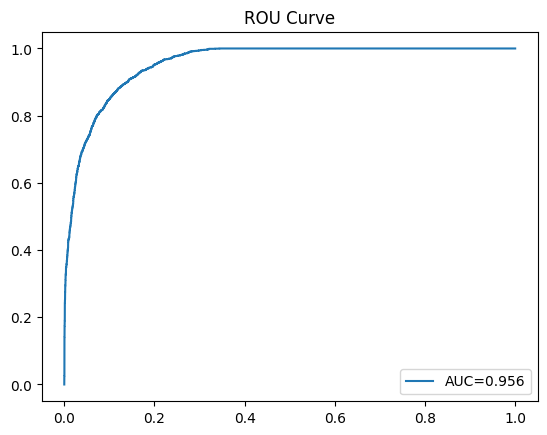

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 문제 19. RandomForestClassifier를 생성하시오.
조건 : 
- n_estimators=100, max_depth=5, random_state=42
- 모델 학습
- Accuracy 계산
- Feature Importance 출력

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_y_pred = rf_model.predict(X_test_scaled)

print(f'accurary : {accuracy_score(y_test, rf_y_pred)}')
print('feature importance : ')
pd.Series(rf_model.feature_importances_, index=X.columns)

accurary : 0.9122222222222223
feature importance : 


person_age                            0.001139
person_income                         0.098281
person_emp_exp                        0.000851
loan_amnt                             0.028172
loan_int_rate                         0.157894
loan_percent_income                   0.192501
cb_person_cred_hist_length            0.000543
credit_score                          0.005531
person_gender_male                    0.000045
person_education_Bachelor             0.000051
person_education_Doctorate            0.000012
person_education_High School          0.000038
person_education_Master               0.000090
person_home_ownership_OTHER           0.000098
person_home_ownership_OWN             0.011190
person_home_ownership_RENT            0.081143
loan_intent_EDUCATION                 0.003037
loan_intent_HOMEIMPROVEMENT           0.002993
loan_intent_MEDICAL                   0.003855
loan_intent_PERSONAL                  0.000493
loan_intent_VENTURE                   0.006193
previous_loan

## 문제 20. 딥러닝(ANN)을 생성하시오.
조건 :
- 모델구조
    - 입력층 (Dense, 32, relu)
    - 은닉층 (Dense, 16, relu)
    - Dropout(0.3)
    - 출력층 (Dense,  1, sigmoid)
- 컴파일 : optimizer='adam', loss='binary_crossentropy', metrics='accuracy'
- 학습 : epochs=20, batch_size=32, validation_split=0.2
- EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model_ann.fit(
    X_train_scaled,
    y_train,
    epochs=20, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[es]
)

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8608 - loss: 0.3005 - val_accuracy: 0.8824 - val_loss: 0.2371
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8919 - loss: 0.2371 - val_accuracy: 0.8894 - val_loss: 0.2306
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8962 - loss: 0.2266 - val_accuracy: 0.8963 - val_loss: 0.2223
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8994 - loss: 0.2188 - val_accuracy: 0.8996 - val_loss: 0.2163
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9046 - loss: 0.2131 - val_accuracy: 0.9025 - val_loss: 0.2098
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9052 - loss: 0.2076 - val_accuracy: 0.9044 - val_loss: 0.2071
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9088 - loss: 0.2047 - val_accuracy: 0.9062 - val_loss: 0.2043
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9083 - loss: 0.2001 - val_accuracy: 0.

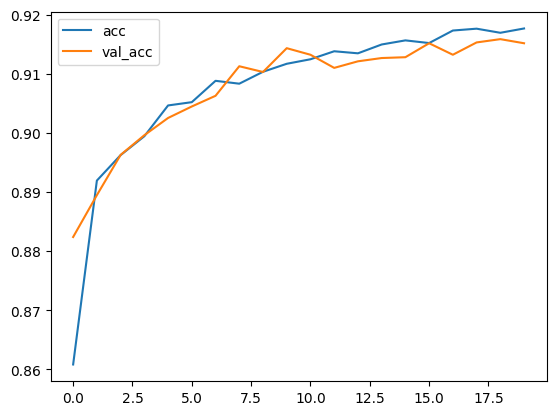

In [63]:
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()